# Variational Autoencoder (VAE) サンプルコード
このコードは授業用に用意したVAEの簡易実装版です。オリジナルの論文の実装とは異なります。<br>
必要な部分を追記することで、[Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist)と呼ばれる衣服の白黒画像データセットを対象に、学習および生成ができます。<br>
(コードを少し書き換えることで他の[データセット](https://pytorch.org/vision/stable/datasets.html)でも学習可能です。）<br>

学習データとモデルは軽量なので、CPUでも実験可能です。<br>
GPUを使う場合はパラメータ設定の「cuda = False」を「cuda = True］に変更してください。<br>
Googleのアカウントを作れば、誰でも無料で[Colaboratory](https://colab.research.google.com/?hl=ja)でGPUを使うことができます。<br>
Colaboratoryにこのノートブックをアップロードして、GPUのランタイムに接続することで実行できます。基本的な使い方はJupyter Notebookと同じです。<br>

コードは7つのStepで構成されています:

0. 準備：ライブラリのインポートやパラメータの定義など<br>
1. データセット読み込み：
2. VAEの定義
3. 損失関数の定義
4. VAEの学習
5. テストデータからの画像再構成
6. ランダムノイズからの画像生成

### 課題
1. Step3について2、3行目のコメントを参考に損失関数を完成させて実行結果を確認しなさい。（仮の値を変数に代入しているので書き直すこと。）<br>
2. 損失関数のKLダイバージェンスに任意の係数をかけてその強弱を調節し、その係数が再構成画像・生成画像の品質に与える影響について考察しなさい。
3. 講義資料や以下の例に示すような、画像生成の応用や潜在変数の可視化分析を自由に実装・実験しなさい。
    - 複数画像間の補間画像を生成。
    - KLD損失の有無や潜在変数の次元数による影響について、テストセットの潜在変数を[t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)などで可視化、画像カテゴリごとに色付けして分析。<br>
（カテゴリIDはStep5の3行目の変数yから取得可。IDとカテゴリ名の対応は[Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist)参照。）

レポートのファイル名やフォーマットは自由。ただし学籍番号、氏名、プログラムのソースコード、実行結果を含め、各課題の回答がわかるように記載し、一つのPDFファイルにして提出すること。

###    Step 0. 準備

In [1]:
!pip install torch torchvision

In [2]:
#ライブラリのインポート
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.datasets import FashionMNIST
import torchvision.transforms as transforms
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
#パラメータの設定
dataset_path = './data' #読み込んだデータセットを保存しておくパス
cuda = False #GPUを使う場合はTrueにする
device = torch.device("cuda" if cuda else "cpu")

latent_dim = 200 #潜在変数の次元数

batch_size = 100 #学習時に1回のパラメータ更新で使う訓練画像の枚数
lr = 1e-3 #学習率(ネットワークの重みパラメータの更新幅)
epochs = 5 #学習回数(全訓練データをモデルに何周学習させるか)

###    Step 1. データセットの読み込み

In [4]:
img_size = 28
img_dim = 784 #入力画像の次元(縦幅x横幅xチャネル数)
#データ読み込み時の前処理のオブジェクトを定義
#（ここでは読み込んだ画像をPyTorchのtensor型に変換する処理を定義）
mnist_transform = transforms.Compose([
        transforms.ToTensor(),
])

#データセットのオブジェクトを定義
train_dataset = FashionMNIST(dataset_path, transform=mnist_transform, train=True, download=True)
test_dataset  = FashionMNIST(dataset_path, transform=mnist_transform, train=False, download=True)

#データセットをロードするためのオブジェクトを定義
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=batch_size, shuffle=False)

### Step 2. VAEの定義

In [5]:
#エンコーダのネットワーク構造を定義
class Encoder(nn.Module):
    
    def __init__(self, input_dim, latent_dim, hidden_dim=400):
        super(Encoder, self).__init__()
        #各層を定義
        self.FC_input = nn.Linear(input_dim, hidden_dim)
        self.FC_input2 = nn.Linear(hidden_dim, hidden_dim)
        self.FC_mean  = nn.Linear(hidden_dim, latent_dim)
        self.FC_var   = nn.Linear (hidden_dim, latent_dim)
        self.LeakyReLU = nn.LeakyReLU(0.2)
        
    def forward(self, x):
        h_       = self.LeakyReLU(self.FC_input(x)) #全結合層→活性化関数
        h_       = self.LeakyReLU(self.FC_input2(h_)) #全結合層→活性化関数
        mean     = self.FC_mean(h_) #平均を推定
        log_var  = self.FC_var(h_) #分散の対数を推定                                                             
        return mean, log_var

#デコーダのネットワーク構造を定義
class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim, hidden_dim=400):
        super(Decoder, self).__init__()
        #各層を定義
        self.FC_hidden = nn.Linear(latent_dim, hidden_dim)
        self.FC_hidden2 = nn.Linear(hidden_dim, hidden_dim)
        self.FC_output = nn.Linear(hidden_dim, output_dim)
        self.LeakyReLU = nn.LeakyReLU(0.2)
        
    def forward(self, x):
        h     = self.LeakyReLU(self.FC_hidden(x)) #全結合層→活性化関数
        h     = self.LeakyReLU(self.FC_hidden2(h)) #全結合層→活性化関数
        
        x_hat = torch.sigmoid(self.FC_output(h)) #全結合層→活性化関数(sigmoidは-1から1を出力)
        return x_hat

#VAEを定義    
class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(Model, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder
        
    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var).to(device)  # 標準正規分布から乱数をサンプリング     
        z = mean + var*epsilon                          # Reparameterization trick
        return z
        
    def forward(self, x):#順伝播の定義
        mean, log_var = self.Encoder(x) #入力画像からエンコーダの出力を計算
        #推定した平均と分散の対数から潜在変数zをサンプリング(標準偏差にするために0.5を掛けてexpをとる)
        z = self.reparameterization(mean, torch.exp(0.5 * log_var)) 
        x_hat = self.Decoder(z) #潜在変数からデコーダの出力を計算
        return x_hat, mean, log_var

#各ネットワークのオブジェクトを定義
encoder = Encoder(input_dim=img_dim, latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim, output_dim=img_dim)
model = Model(Encoder=encoder, Decoder=decoder).to(device)

### Step 3. 損失関数の定義

#### 課題のヒント
- 損失関数の引数の説明
    - x：入力画像のテンソル
    - x_hat：再構成画像のテンソル
    - mean：エンコーダが推定した平均のテンソル
    - log_bar：エンコーダが推定した対数分散のテンソル

- 課題で使うことを想定した演算・関数
    - テンソルどうしは + や - で加算減算が可能
    - (テンソル)**2：テンソルの各要素を二乗する
    - (テンソル).sum()：テンソルの各要素の和をとる
    - (テンソル).exp()：テンソルの各要素のexponentialをとる

In [6]:
def loss_function(x, x_hat, mean, log_var):
    reconstruction_loss = ((x - x_hat)**2).sum() #入力画像xと再構成画像x_hatの再構成誤差を計算
    KLD      = -0.5*(1 + log_var - mean**2 - log_var.exp()).sum() #平均meanかつ対数分散log_varの正規分布と、標準正規分布とのKLダイバージェンスを計算
    return reconstruction_loss + KLD

### Step 4. VAEの学習

In [7]:
#ニューラルネットの重みパラメータを最適化するためのオプティマイザを定義
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
model.train()#モデルを訓練モードに切り替え
print("Start training VAE...")

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in tqdm(enumerate(train_loader), total=len(train_loader)):#画像とカテゴリIDをbatch_size個ずつxとyに格納
        x = x.view(batch_size, img_dim)#(batch_size,縦幅,横幅)のテンソルを(batch_size,縦幅x横幅)のテンソルに変換
        x = x.to(device)#GPUで処理する場合はデータをGPUに移動、CPUの場合はそのまま

        optimizer.zero_grad()#最適化器を初期化

        x_hat, mean, log_var = model(x)#xに対してVAEモデルを順伝播し再構成画像、潜在空間の平均、分散の対数を推定
        loss = loss_function(x, x_hat, mean, log_var)#損失関数を計算
        
        overall_loss += loss.item()#損失の総和を計算
        
        loss.backward()#誤差伝播法によりネットワークの重みパラメータに対する勾配を計算
        optimizer.step()#重みパラメータの更新
        
    print("\tEpoch", epoch + 1, "complete!", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training VAE...


  0%|          | 0/600 [00:00<?, ?it/s]

	Epoch 1 complete! 	Average Loss:  41.859729843521755


  0%|          | 0/600 [00:00<?, ?it/s]

	Epoch 2 complete! 	Average Loss:  29.74139542466611


...

	Epoch 3 complete! 	Average Loss:  27.29563101181005


  0%|          | 0/600 [00:00<?, ?it/s]

	Epoch 4 complete! 	Average Loss:  26.5654337388486


  0%|          | 0/600 [00:00<?, ?it/s]

	Epoch 5 complete! 	Average Loss:  26.17808544840359
Finish!!


### Step 5. テストデータからの画像再構成

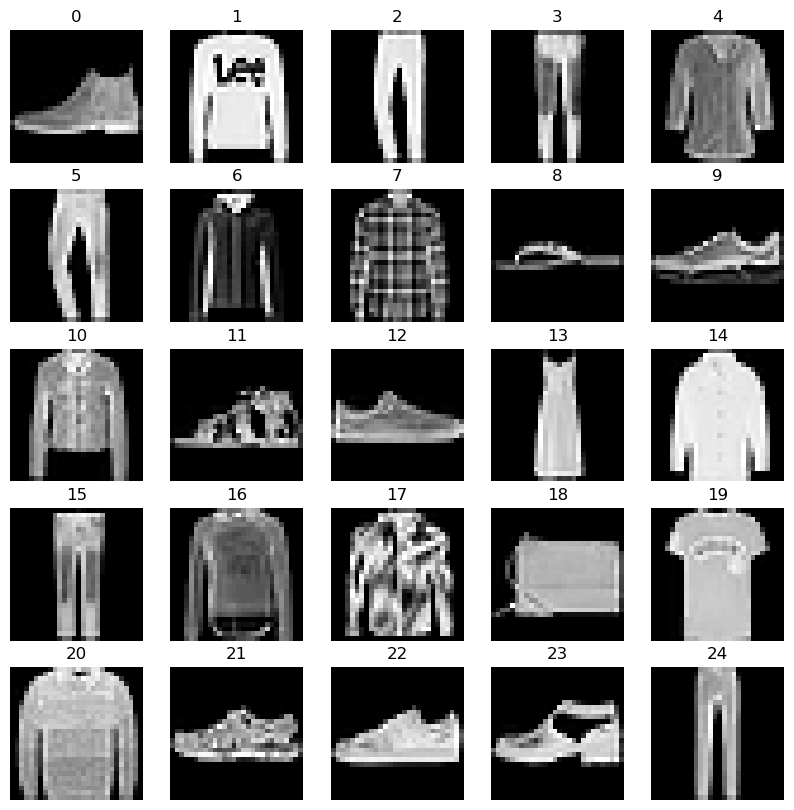

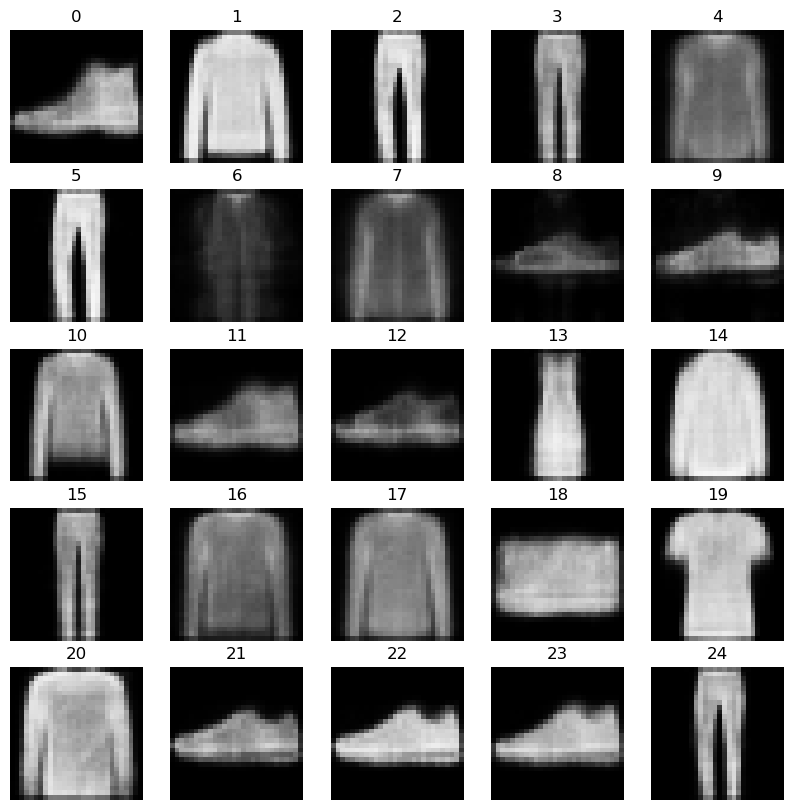

In [8]:
model.eval()#モデルを評価モードに切り替え
with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_loader):#xは画像のバッチ, yはカテゴリIDのバッチ
        x = x.view(batch_size, img_dim)
        x = x.to(device) 
        x_hat, _, _ = model(x)
        break

def show_images(x,n_row=5, n_col=5):
    x = x.view(batch_size, img_size, img_size, 1).repeat((1,1,1,3))
    plt.figure(figsize=(10, 10))
    for i in range(n_row*n_col):
        plt.subplot(n_row, n_col, i+1)
        plt.title(i)
        plt.imshow(x[i].cpu().numpy())
        plt.axis('off')
    
show_images(x)
show_images(x_hat)

In [ ]:
show

### Step 6. ランダムノイズからの画像生成

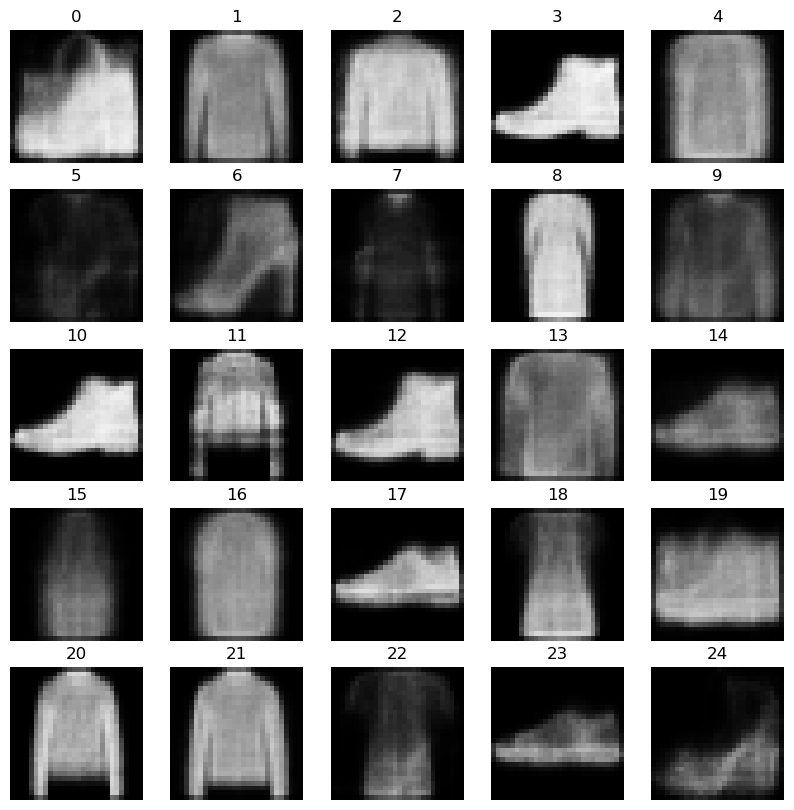

In [9]:
model.eval()
with torch.no_grad():
    noise = torch.randn(batch_size, latent_dim).to(device)
    generated_images = decoder(noise)

show_images(generated_images)